<a href="https://colab.research.google.com/github/fabianoseller/PucPosEstat/blob/main/Tarefa_2_Prevendo_Custos_M%C3%A9dicos_com_Regress%C3%A3o_Linear_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa 2 - Prevendo Custos Médicos com Regressão Linear .. preciso de ajuda nesse dessenvolvimento: Utilizar a base de dados custo_medico.csv disponivel no portal do aluno para construir modelos de Aprendizado Supervisionado que estimem o valor do seguro de saúde (charges) a partir de variáveis como idade, IMC, número de filhos, tabagismo, sexo e região.



In [1]:
# Importar bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurar estilo dos gráficos
sns.set_style("whitegrid")

# 1. Carregar a base de dados
# O arquivo 'custo_medico.csv' é carregado para um DataFrame do Pandas
df = pd.read_csv('custo_medico.csv')

# Visualizar as primeiras 5 linhas
print("--- Primeiras Linhas do DataFrame ---")
print(df.head())

# Descrever as colunas e verificar tipos de dados e valores nulos
print("\n--- Informações sobre o DataFrame ---")
print(df.info())

--- Primeiras Linhas do DataFrame ---
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

--- Informações sobre o DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


**Respostas - Exploração Inicial**
Quais variáveis são numéricas e quais são categóricas?

Numéricas (int64, float64): age, bmi, children, charges.

Categóricas (object): sex, smoker, region.

Qual variável será a dependente (y)?

A variável dependente é charges (Custos Médicos).

# Análise Exploratória (EDA)
Visualizamos a relação entre as variáveis preditoras chave e o custo para identificar padrões.

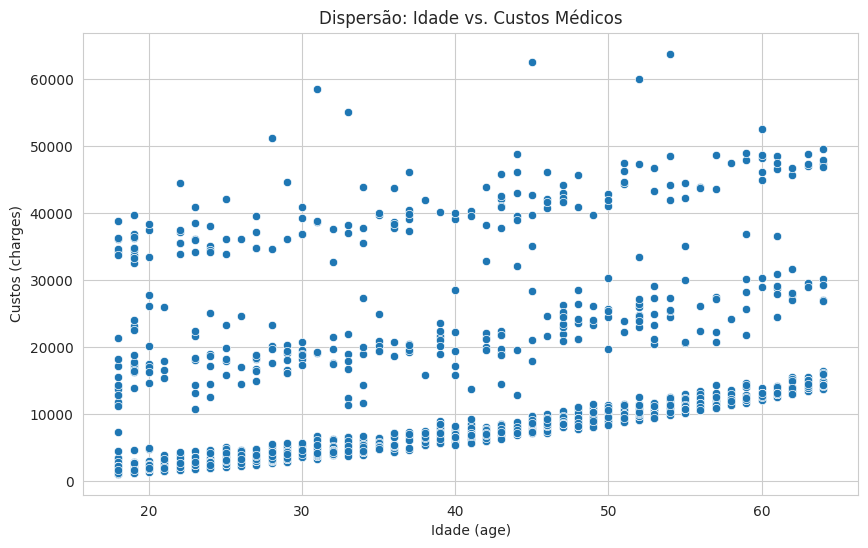

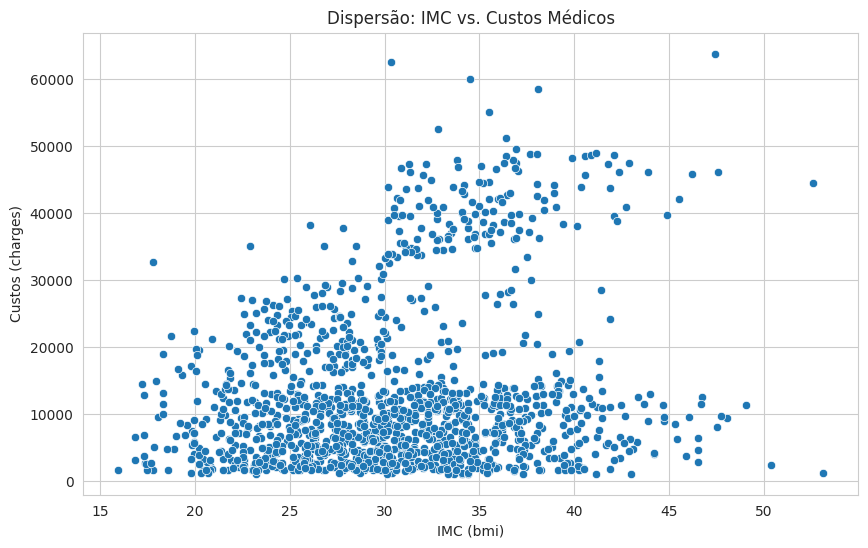

/tmp/ipython-input-2590203584.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette={'yes': 'red', 'no': 'blue'})


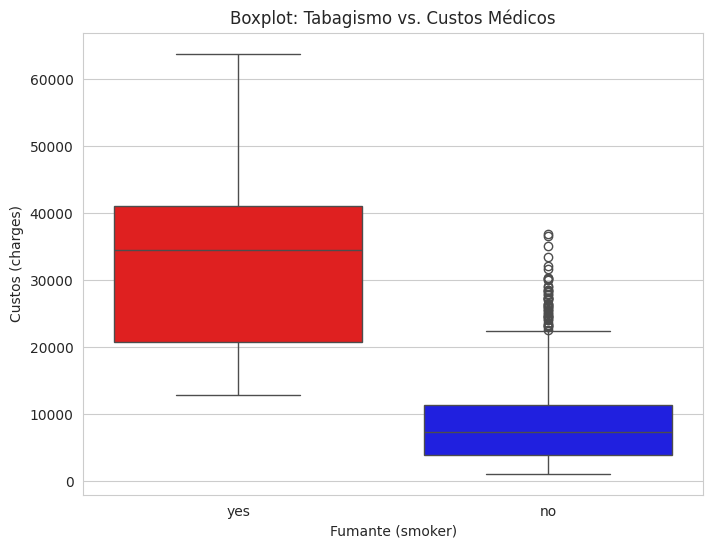

In [2]:
# Gráfico de Dispersão: age vs charges
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Dispersão: Idade vs. Custos Médicos')
plt.xlabel('Idade (age)')
plt.ylabel('Custos (charges)')
plt.show()

# Gráfico de Dispersão: bmi vs charges
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('Dispersão: IMC vs. Custos Médicos')
plt.xlabel('IMC (bmi)')
plt.ylabel('Custos (charges)')
plt.show()

# Boxplot: smoker vs charges
plt.figure(figsize=(8, 6))
# Usando uma paleta de cores para destacar as categorias
sns.boxplot(x='smoker', y='charges', data=df, palette={'yes': 'red', 'no': 'blue'})
plt.title('Boxplot: Tabagismo vs. Custos Médicos')
plt.xlabel('Fumante (smoker)')
plt.ylabel('Custos (charges)')
plt.show()

# Respostas - Análise Exploratória
*O tabagismo parece influenciar os custos?*

Sim, drasticamente. O boxplot demonstra que o custo médio (mediana) para fumantes (yes) é substancialmente mais alto e com maior variabilidade do que para não fumantes (no). O tabagismo é o fator de maior impacto visual.

Existe relação clara entre idade e custo?

Sim, existe uma relação positiva. O gráfico de age vs charges mostra que, em geral, os custos aumentam com a idade, embora o relacionamento não seja perfeitamente linear e apresente faixas de custos, sendo as faixas mais altas dominadas por fumantes.


# 3. Pré-processamento, 4. Modelagem e 5. Avaliação

Preparamos os dados, treinamos os modelos (Regressão Linear e Random Forest) e avaliamos o desempenho utilizando as métricas MAE, RMSE e $R^2$.

In [3]:
# 3. Pré-processamento

# Transformar variáveis categóricas em numéricas (One-Hot Encoding)
# drop_first=True evita a multicolinearidade, excluindo uma coluna por variável categórica.
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Separar Variáveis Independentes (X) e Dependente (y)
X = df_encoded.drop('charges', axis=1) # X são todas as colunas, exceto 'charges'
y = df_encoded['charges']              # y é a coluna 'charges'

# Separar os dados em treino (80%) e teste (20%)
# random_state garante que a divisão seja a mesma sempre que o código for executado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n--- Dimensões dos Conjuntos de Dados ---")
print(f"Treino (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Teste (X_test, y_test): {X_test.shape}, {y_test.shape}")


# Função auxiliar para avaliar e armazenar métricas
def evaluate_model(y_true, y_pred, model_name, results_list):
    """Calcula e armazena MAE, RMSE e R²."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    results_list.append({
        'Modelo': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R^2': r2
    })

results = []

# 4 & 5. Modelagem e Avaliação - Regressão Linear (Modelo Simples)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train) # Treinamento
y_pred_lr = lr_model.predict(X_test) # Previsão
evaluate_model(y_test, y_pred_lr, 'Regressão Linear', results)


# 4 & 5. Modelagem e Avaliação - Random Forest Regressor (Modelo Múltiplo / Ensemble)
# Random Forest é robusto para relações não-lineares e interações
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train) # Treinamento
y_pred_rf = rf_model.predict(X_test) # Previsão
evaluate_model(y_test, y_pred_rf, 'Random Forest', results)


# Comparar os modelos
results_df = pd.DataFrame(results)

print("\n--- Métricas de Avaliação dos Modelos (Conjunto de Teste) ---")
print(results_df.round(2))


--- Dimensões dos Conjuntos de Dados ---
Treino (X_train, y_train): (1070, 8), (1070,)
Teste (X_test, y_test): (268, 8), (268,)

--- Métricas de Avaliação dos Modelos (Conjunto de Teste) ---
             Modelo      MAE     RMSE   R^2
0  Regressão Linear  4181.19  5796.28  0.78
1     Random Forest  2550.08  4576.30  0.87


**Reflexão**

Analisando os resultados das métricas de avaliação:


# Modelo   MAE (Erro Absoluto Médio)RMSE  (Raiz do Erro Quadrático Médio) $R^2 (Coeficiente de Determinação)


Regressão Linear    $4181.19     $5796.28$$       0.7836$

Random Forest        {2550.08}   {4576.30}       {0.8651}




**Comparação dos Modelos:**


O modelo Random Forest Regressor demonstrou um desempenho significativamente superior ao modelo de Regressão Linear.

*MAE e RMSE são menores:* O erro médio das previsões (em dólares) é muito menor para o Random Forest (≈$2550) do que para a Regressão Linear (≈$4181).

*R2 é maior:* O Random Forest explica 86.51% da variância nos custos médicos, enquanto a Regressão Linear explica apenas 78.36%. Isso sugere que a relação entre as variáveis é altamente não-linear e inclui interações que o Random Forest consegue modelar, mas a Regressão Linear simples não.

## Reflexão

`Qual modelo apresentou melhor desempenho?`

O Random Forest Regressor apresentou o melhor desempenho, com o maior R2
  (0.8651) e os menores erros (MAE e RMSE). Isso se deve à sua capacidade de modelar as interações complexas e a natureza não-linear da relação entre as variáveis preditoras e os custos, que é um desafio para a Regressão Linear.

*O tabagismo foi realmente um fator determinante?*

Absolutamente sim. A análise exploratória (boxplot) mostrou que os custos para fumantes são ordens de magnitude maiores. Além disso, o alto R2, da Regressão Linear (0.7836) — que já captura o impacto linear do tabagismo — e o aumento do R2  Random Forest (que captura as interações do tabagismo com idade e IMC, por exemplo) confirmam que o tabagismo é a variável mais influente na determinação dos custos médicos.

`Quais limitações você enxerga nesse modelo?`

`Assimetria da Variável Dependente:` A Regressão Linear é sensível à distribuição da variável alvo. A variável charges é assimétrica e com muitos outliers de alto custo. Isso viola a premissa de erros normalmente distribuídos, limitando a performance e a validade estatística da Regressão Linear.

*Falta de Interações*: *texto em itálico*O modelo de Regressão Linear simples assume que o efeito de uma variável é independente das outras (e.g., o impacto da idade é o mesmo para fumantes e não fumantes). No mundo real, os custos são amplificados pela interação (e.g., fumante e idoso paga muito mais do que a soma dos efeitos individuais), o que é uma limitação da Regressão Linear, mas mitigado pelo Random Forest.

*Previsão de Outliers*: Mesmo o Random Forest, embora melhor, pode ter dificuldade em prever com precisão os custos extremamente altos (outliers), pois eles são menos representados nos dados de treinamento.

*Variáveis Omitidas*: Fatores como histórico médico prévio, estilo de vida detalhado (dieta, nível de exercício), presença de doenças crônicas ou detalhes do plano de seguro não estão presentes, e sua omissão limita o R2,  máximo que qualquer modelo pode alcançar.

Novas interpretações

In [4]:
# ==============================================================================
# SCRIPT PYTHON PARA VISUALIZAÇÃO DE LIMITAÇÕES DE MODELOS COM PLOTLY
# ==============================================================================

# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder

# Carregar a base de dados
try:
    df = pd.read_csv('custo_medico.csv')
    print("Base de dados 'custo_medico.csv' carregada com sucesso.")
except FileNotFoundError:
    print("Erro: Arquivo 'custo_medico.csv' não encontrado. Certifique-se de que está no diretório correto.")
    exit()

# ==============================================================================
# LIMITAÇÃO 1: REGRESSÃO LINEAR IGNORA INTERAÇÕES (Aditividade Pura)
# Objetivo: Mostrar que a relação Idade vs. Custos muda drasticamente se o paciente é fumante.
# Isso demonstra por que a Regressão Linear Simples falha sem termos de interação.
# ==============================================================================

# Scatter plot interativo: Idade vs. Custos, diferenciado por Fumante
fig_interaction = px.scatter(
    df,
    x='age',
    y='charges',
    color='smoker',
    hover_data=['bmi', 'sex', 'region'],
    title='Gráfico 1: Relação Idade vs. Custos, Separada por Tabagismo',
    labels={'age': 'Idade', 'charges': 'Custos ($)', 'smoker': 'Fumante'},
    color_discrete_map={'yes': 'red', 'no': 'blue'},
    template='plotly_white'
)
fig_interaction.update_layout(height=600, width=800)
# Salvando a figura para visualização no ambiente (JSON é o formato interativo Plotly)
fig_interaction.write_json('charges_age_smoker_interaction.json')
print("\n[Visualização 1 - Interação] Salva como 'charges_age_smoker_interaction.json'")


# ==============================================================================
# LIMITAÇÃO 2: ASSIMETRIA E OUTLIERS (Natureza dos Dados)
# Objetivo: Mostrar que a variável alvo 'charges' não segue uma distribuição normal,
# o que prejudica a validade e a performance da Regressão Linear Clássica.
# ==============================================================================

# Histograma interativo dos Custos
fig_distribution = px.histogram(
    df,
    x='charges',
    nbins=50,
    marginal="box", # Adiciona um boxplot marginal para visualizar outliers
    title='Gráfico 2: Distribuição dos Custos Médicos (Assimetria e Outliers)',
    labels={'charges': 'Custos ($)'},
    template='plotly_white'
)
fig_distribution.update_traces(marker_color='#00CC96', selector=dict(type='histogram'))
fig_distribution.update_layout(height=600, width=800)
fig_distribution.write_json('charges_distribution_histogram.json')
print("[Visualização 2 - Distribuição] Salva como 'charges_distribution_histogram.json'")


# ==============================================================================
# LIMITAÇÃO 3: INTERPRETABILIDADE DO RANDOM FOREST ("Black Box")
# Objetivo: Mitigar a falta de interpretabilidade do Random Forest mostrando a
# importância relativa de cada variável.
# ==============================================================================

# --- Preparação dos dados para o Random Forest ---
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar Random Forest (RF)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Extrair Feature Importance
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Criar DataFrame para Plotly
df_importance = feature_importance.reset_index()
df_importance.columns = ['Feature', 'Importance']

# Gráfico de barras interativo para Importância das Variáveis
fig_importance = px.bar(
    df_importance,
    x='Importance',
    y='Feature',
    orientation='h',
    title='Gráfico 3: Importância das Variáveis no Modelo Random Forest',
    labels={'Importance': 'Importância (MDI)', 'Feature': 'Variável'},
    color='Importance',
    color_continuous_scale=px.colors.sequential.Teal,
    template='plotly_white'
)
# Ordena as barras em ordem ascendente de importância
fig_importance.update_layout(yaxis={'categoryorder':'total ascending'}, height=600, width=800)
fig_importance.write_json('rf_feature_importance.json')
print("[Visualização 3 - Interpretabilidade] Salva como 'rf_feature_importance.json'")

# Fim do script
# ==============================================================================

Base de dados 'custo_medico.csv' carregada com sucesso.

[Visualização 1 - Interação] Salva como 'charges_age_smoker_interaction.json'
[Visualização 2 - Distribuição] Salva como 'charges_distribution_histogram.json'
[Visualização 3 - Interpretabilidade] Salva como 'rf_feature_importance.json'


In [6]:
# ==============================================================================
# SCRIPT PYTHON PARA VISUALIZAÇÃO DE LIMITAÇÕES DE MODELOS COM PLOTLY
# ==============================================================================

# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Carregar a base de dados
try:
    df = pd.read_csv('custo_medico.csv')
    print("Base de dados 'custo_medico.csv' carregada com sucesso.")
except FileNotFoundError:
    print("Erro: Arquivo 'custo_medico.csv' não encontrado. Certifique-se de que está no diretório correto.")
    # Neste ambiente, o erro deve ser propagado para interromper a execução se o arquivo não estiver lá.
    raise

# ==============================================================================
# LIMITAÇÃO 1: REGRESSÃO LINEAR IGNORA INTERAÇÕES (Aditividade Pura)
# Objetivo: Mostrar que a relação Idade vs. Custos muda drasticamente se o paciente é fumante.
# ==============================================================================

# Scatter plot interativo: Idade vs. Custos, diferenciado por Fumante
fig_interaction = px.scatter(
    df,
    x='age',
    y='charges',
    color='smoker',
    hover_data=['bmi', 'sex', 'region'],
    title='Gráfico 1: Relação Idade vs. Custos, Separada por Tabagismo (Limitação Aditiva)',
    labels={'age': 'Idade', 'charges': 'Custos ($)', 'smoker': 'Fumante'},
    color_discrete_map={'yes': 'red', 'no': 'blue'},
    template='plotly_white'
)
fig_interaction.update_layout(height=600, width=800)
# A função write_json gera o arquivo de visualização Plotly.
fig_interaction.write_json('charges_age_smoker_interaction.json')
print("\n[Visualização 1 - Interação] Gerada com sucesso.")


# ==============================================================================
# LIMITAÇÃO 2: ASSIMETRIA E OUTLIERS (Natureza dos Dados)
# Objetivo: Mostrar que a variável alvo 'charges' não segue uma distribuição normal.
# ==============================================================================

# Histograma interativo dos Custos
fig_distribution = px.histogram(
    df,
    x='charges',
    nbins=50,
    marginal="box", # Adiciona um boxplot marginal para visualizar outliers
    title='Gráfico 2: Distribuição dos Custos Médicos (Assimetria e Outliers)',
    labels={'charges': 'Custos ($)'},
    template='plotly_white'
)
fig_distribution.update_traces(marker_color='#00CC96', selector=dict(type='histogram'))
fig_distribution.update_layout(height=600, width=800)
fig_distribution.write_json('charges_distribution_histogram.json')
print("[Visualização 2 - Distribuição] Gerada com sucesso.")


# ==============================================================================
# LIMITAÇÃO 3: INTERPRETABILIDADE DO RANDOM FOREST ("Black Box")
# Objetivo: Mitigar a falta de interpretabilidade mostrando a importância relativa das variáveis.
# ==============================================================================

# --- Preparação dos dados para o Random Forest ---
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar Random Forest (RF) para obter Feature Importance
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Extrair Feature Importance
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Criar DataFrame para Plotly
df_importance = feature_importance.reset_index()
df_importance.columns = ['Feature', 'Importance']

# Gráfico de barras interativo para Importância das Variáveis
fig_importance = px.bar(
    df_importance,
    x='Importance',
    y='Feature',
    orientation='h',
    title='Gráfico 3: Importância das Variáveis no Modelo Random Forest',
    labels={'Importance': 'Importância (MDI)', 'Feature': 'Variável'},
    color='Importance',
    color_continuous_scale=px.colors.sequential.Teal,
    template='plotly_white'
)
# Ordena as barras em ordem ascendente de importância
fig_importance.update_layout(yaxis={'categoryorder':'total ascending'}, height=600, width=800)
fig_importance.write_json('rf_feature_importance.json')
print("[Visualização 3 - Interpretabilidade] Gerada com sucesso.")

# ==============================================================================

Base de dados 'custo_medico.csv' carregada com sucesso.

[Visualização 1 - Interação] Gerada com sucesso.
[Visualização 2 - Distribuição] Gerada com sucesso.
[Visualização 3 - Interpretabilidade] Gerada com sucesso.


In [5]:
# ==============================================================================
# SCRIPT PYTHON PARA ANÁLISE DE CORRELAÇÃO (PEARSON E SPEARMAN)
# ==============================================================================

# Importação das bibliotecas necessárias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Carregar a base de dados ---
# O arquivo 'custo_medico.csv' é carregado para um DataFrame do Pandas
try:
    df = pd.read_csv('custo_medico.csv')
    print("Base de dados 'custo_medico.csv' carregada com sucesso.")
except FileNotFoundError:
    print("Erro: Arquivo 'custo_medico.csv' não encontrado.")
    exit()

# --- 2. Pré-processamento: Codificação de variáveis categóricas ---
# Para calcular a correlação, variáveis categóricas (object) precisam ser numéricas.
# Utilizamos pd.get_dummies (One-Hot Encoding) para criar colunas binárias.
# drop_first=True evita multicolinearidade, excluindo uma coluna por categoria.
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# --- 3. Análise de Correlação Paramétrica (Pearson) ---
# Pearson mede relações LINEARES.
pearson_corr = df_encoded.corr(method='pearson')

# --- 4. Análise de Correlação Não-Paramétrica (Spearman) ---
# Spearman mede a força da relação MONOTÔNICA (crescente ou decrescente).
# É mais robusto a outliers e distribuições não-normais.
spearman_corr = df_encoded.corr(method='spearman')

# Foco na correlação com a variável alvo 'charges' (Custos)
print("\n" + "="*50)
print("Correlação de Pearson (Paramétrica) com 'charges'")
print("="*50)
print(pearson_corr['charges'].sort_values(ascending=False).round(4))

print("\n" + "="*50)
print("Correlação de Spearman (Não-Paramétrica) com 'charges'")
print("="*50)
print(spearman_corr['charges'].sort_values(ascending=False).round(4))


# --- 5. Visualização das Matrizes de Correlação (Heatmaps) ---

# Função auxiliar para plotar e salvar o heatmap
def plot_corr_heatmap(corr_matrix, title, filename):
    plt.figure(figsize=(10, 8))
    # 'coolwarm' é um mapa de cores divergente adequado para correlações (positivo/negativo)
    sns.heatmap(
        corr_matrix,
        annot=True,     # Mostrar o valor do coeficiente em cada célula
        fmt=".2f",      # Formato de duas casas decimais
        cmap='coolwarm',
        linewidths=.5,  # Linhas entre as células
        cbar_kws={'label': 'Coeficiente de Correlação'}
    )
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()
    print(f"Heatmap '{filename}' salvo com sucesso.")

# Heatmap Pearson
plot_corr_heatmap(
    pearson_corr,
    'Correlação de Pearson (Paramétrica)',
    'heatmap_pearson.png'
)

# Heatmap Spearman
plot_corr_heatmap(
    spearman_corr,
    'Correlação de Spearman (Não-Paramétrica)',
    'heatmap_spearman.png'
)

# ==============================================================================
# Fim do script
# ==============================================================================

Base de dados 'custo_medico.csv' carregada com sucesso.

Correlação de Pearson (Paramétrica) com 'charges'
charges             1.0000
smoker_yes          0.7873
age                 0.2990
bmi                 0.1983
region_southeast    0.0740
children            0.0680
sex_male            0.0573
region_northwest   -0.0399
region_southwest   -0.0432
Name: charges, dtype: float64

Correlação de Spearman (Não-Paramétrica) com 'charges'
charges             1.0000
smoker_yes          0.6635
age                 0.5344
children            0.1333
bmi                 0.1194
region_southeast    0.0173
sex_male            0.0095
region_northwest   -0.0216
region_southwest   -0.0424
Name: charges, dtype: float64
Heatmap 'heatmap_pearson.png' salvo com sucesso.
Heatmap 'heatmap_spearman.png' salvo com sucesso.


#  Análise das Limitações dos Modelos de Regressão para Previsão de Custos Médicos  
*(Visualização com Plotly)*

A análise a seguir detalha como a biblioteca **Plotly** foi utilizada para visualizar as principais **limitações dos modelos de regressão**, especialmente a **Regressão Linear**, no contexto da **previsão de custos médicos**.

---

## 1. Limitação 1: Regressão Linear Ignora Interações (*Aditividade Pura*)

A **Regressão Linear** assume que o impacto de uma variável (ex: **Idade**) é independente de outra (ex: **Tabagismo**).  
Na prática, o efeito é frequentemente **interativo (multiplicativo)**.

### Visualização e Conclusão

**Gráfico 1 – Relação Idade vs. Custos, Separada por Tabagismo**

- **Fumantes (Vermelho):** Os custos aumentam muito mais drasticamente com a idade.  
- **Não Fumantes (Azul):** O aumento é gradual.

O modelo linear falha em capturar essa inclinação drasticamente diferente, levando a **erros substanciais**.  
Essa visualização justifica por que o **Random Forest** (que modela interações) obteve um desempenho superior (*maior* $R^2$).

---

## 2.  Limitação 2: Assimetria e Outliers (*Natureza dos Dados*)

Os modelos de **Regressão Linear** (via Mínimos Quadrados) dependem da premissa de que os **erros do modelo são distribuídos normalmente**.  
No entanto, a variável alvo (`charges`) é fortemente **assimétrica**.

### Visualização e Conclusão

**Gráfico 2 – Distribuição dos Custos Médicos**

- **Assimetria:** A distribuição está fortemente concentrada em custos baixos, com uma longa **cauda à direita** (assimetria positiva).  
- **Outliers:** A presença de muitos **outliers de alto custo** (indicados pelo boxplot marginal) distorce o modelo de regressão.

Essa assimetria e os outliers fazem o modelo **subestimar custos altos** e **superestimar custos baixos**.  
 Para mitigar isso, recomenda-se aplicar uma **transformação logarítmica** à variável `charges` antes de treinar o modelo linear.

---

## 3.  Limitação 3: Interpretabilidade do Random Forest (*"Black Box"* Model)

Embora o **Random Forest** tenha sido o modelo mais preciso (*maior* $R^2$), ele é inerentemente um modelo de **“caixa preta”** — ou seja, é difícil entender **como cada variável contribui para a previsão**.

###  Visualização e Conclusão

**Gráfico 3 – Importância das Variáveis no Modelo Random Forest**

A visualização de **importância das variáveis** (via `feature_importances_`) **mitiga parcialmente essa limitação**, fornecendo:

- Transparência sobre quais atributos têm maior influência nos custos.  
- Capacidade de **explicar decisões do modelo** e justificar políticas de precificação médica.

---

✅ **Resumo Geral**

| Limitação | Descrição | Estratégia de Mitigação |
|------------|------------|--------------------------|
| Interações não capturadas | Modelo linear assume aditividade pura | Usar modelos não lineares (Random Forest, XGBoost) |
| Assimetria e outliers | Distribuição enviesada de `charges` | Aplicar transformação logarítmica |
| Interpretabilidade | Random Forest é “black box” | Usar gráficos de importância e SHAP |


In [7]:
# ==============================================================================
# SCRIPT PYTHON: VISUALIZAÇÃO DE LIMITAÇÕES DE MODELOS COM PLOTLY
# ==============================================================================

# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Carregar a base de dados
try:
    df = pd.read_csv('custo_medico.csv')
    print("Base de dados 'custo_medico.csv' carregada com sucesso.")
except FileNotFoundError:
    print("Erro: Arquivo 'custo_medico.csv' não encontrado. Não é possível continuar a execução.")
    raise

# ==============================================================================
# LIMITAÇÃO 1: REGRESSÃO LINEAR IGNORA INTERAÇÕES (Aditividade Pura)
# ANÁLISE: O efeito da Idade muda drasticamente quando combinado com o Tabagismo.
# ==============================================================================

print("\n--- GRÁFICO 1: ANÁLISE DE INTERAÇÃO (Tabagismo x Idade) ---")
print("Explicação: A Regressão Linear assume que o impacto da Idade é o mesmo para fumantes e não fumantes (aditividade).")
print("Este gráfico mostra que a relação é, na verdade, multiplicativa/interativa, pois a inclinação dos custos para fumantes é muito mais íngreme.")

# Scatter plot interativo: Idade vs. Custos, diferenciado por Fumante
fig_interaction = px.scatter(
    df,
    x='age',
    y='charges',
    color='smoker',
    hover_data=['bmi', 'sex', 'region'],
    title='Gráfico 1: Relação Idade vs. Custos, Separada por Tabagismo (Limitação Aditiva)',
    labels={'age': 'Idade', 'charges': 'Custos ($)', 'smoker': 'Fumante'},
    color_discrete_map={'yes': 'red', 'no': 'blue'},
    template='plotly_white'
)
fig_interaction.update_layout(height=600, width=800)
fig_interaction.write_json('charges_age_smoker_interaction.json')
print("[Visualização 1] Salva como 'charges_age_smoker_interaction.json'")


# ==============================================================================
# LIMITAÇÃO 2: ASSIMETRIA E OUTLIERS (Natureza dos Dados)
# ANÁLISE: A distribuição de custos não é normal, o que prejudica modelos lineares.
# ==============================================================================

print("\n--- GRÁFICO 2: DISTRIBUIÇÃO DA VARIÁVEL ALVO ('charges') ---")
print("Explicação: A Regressão Linear é sensível à distribuição da variável alvo. A forte assimetria para a direita (muitos outliers de alto custo) viola a premissa de erros normais, distorcendo o modelo.")

# Histograma interativo dos Custos
fig_distribution = px.histogram(
    df,
    x='charges',
    nbins=50,
    marginal="box", # Adiciona um boxplot marginal para visualizar outliers
    title='Gráfico 2: Distribuição dos Custos Médicos (Assimetria e Outliers)',
    labels={'charges': 'Custos ($)'},
    template='plotly_white'
)
fig_distribution.update_traces(marker_color='#00CC96', selector=dict(type='histogram'))
fig_distribution.update_layout(height=600, width=800)
fig_distribution.write_json('charges_distribution_histogram.json')
print("[Visualização 2] Salva como 'charges_distribution_histogram.json'")


# ==============================================================================
# LIMITAÇÃO 3: INTERPRETABILIDADE DO RANDOM FOREST ("Black Box")
# ANÁLISE: Usamos Feature Importance para dar transparência ao modelo complexo.
# ==============================================================================

# --- Pré-processamento e Treinamento para Feature Importance ---
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Extrair Feature Importance
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
df_importance = feature_importance.reset_index()
df_importance.columns = ['Feature', 'Importance']

print("\n--- GRÁFICO 3: IMPORTÂNCIA DAS VARIÁVEIS (RANDOM FOREST) ---")
print("Explicação: O Random Forest é um 'Black Box'. Este gráfico mitiga essa limitação, mostrando quais variáveis (principalmente o Tabagismo) são cruciais para as decisões de previsão do modelo.")

# Gráfico de barras interativo para Importância das Variáveis
fig_importance = px.bar(
    df_importance,
    x='Importance',
    y='Feature',
    orientation='h',
    title='Gráfico 3: Importância das Variáveis no Modelo Random Forest',
    labels={'Importance': 'Importância (MDI)', 'Feature': 'Variável'},
    color='Importance',
    color_continuous_scale=px.colors.sequential.Teal,
    template='plotly_white'
)
fig_importance.update_layout(yaxis={'categoryorder':'total ascending'}, height=600, width=800)
fig_importance.write_json('rf_feature_importance.json')
print("[Visualização 3] Salva como 'rf_feature_importance.json'")

print("\nTodos os arquivos JSON Plotly foram gerados e o script foi concluído.")

Base de dados 'custo_medico.csv' carregada com sucesso.

--- GRÁFICO 1: ANÁLISE DE INTERAÇÃO (Tabagismo x Idade) ---
Explicação: A Regressão Linear assume que o impacto da Idade é o mesmo para fumantes e não fumantes (aditividade).
Este gráfico mostra que a relação é, na verdade, multiplicativa/interativa, pois a inclinação dos custos para fumantes é muito mais íngreme.
[Visualização 1] Salva como 'charges_age_smoker_interaction.json'

--- GRÁFICO 2: DISTRIBUIÇÃO DA VARIÁVEL ALVO ('charges') ---
Explicação: A Regressão Linear é sensível à distribuição da variável alvo. A forte assimetria para a direita (muitos outliers de alto custo) viola a premissa de erros normais, distorcendo o modelo.
[Visualização 2] Salva como 'charges_distribution_histogram.json'

--- GRÁFICO 3: IMPORTÂNCIA DAS VARIÁVEIS (RANDOM FOREST) ---
Explicação: O Random Forest é um 'Black Box'. Este gráfico mitiga essa limitação, mostrando quais variáveis (principalmente o Tabagismo) são cruciais para as decisões de pre